# Cantilever Beam: Solid-Frame Coupling with Duplicated Nodes

This example demonstrates how to couple **solid** (continuum) elements with **frame** (beam-column) elements in OpenSees using the **duplicated-node technique** with rigid links and `equalDOF` constraints.

## Problem Description

A cantilever beam of length $L$ under a point load $P$ at the free end:

- **Left half** ($0 \le x \le L/2$): modeled with solid elements
- **Right half** ($L/2 \le x \le L$): modeled with a single frame element
- **Fixed support** at $x = 0$
- **Point load** $P$ at $x = L$ (free end)

```
  Fixed                                              Point load P
  |||||                                                    |
  |||||  SOLID (shell)         |  FRAME (beam-column)      v
  |||||========================|===========================*
  |||||  nx x ny elements      |  master       tip
  |||||                        |
  |||||________________________|
  x=0                        x=L/2                       x=L
```

## Why Duplicated Nodes?

### The DOF Incompatibility Problem

Solid elements (bricks, tets, quads) have **only translational DOFs** at each node — there is no rotational stiffness because the continuum formulation captures rotations through the displacement field gradient, not through explicit nodal rotations.

Frame (beam-column) elements have **both translational and rotational DOFs** — the rotation $\theta_z$ is an independent unknown at each node.

If you use `rigidLink('beam', masterNode, solidNode)` directly on a solid element node, you are imposing rotational DOFs on a node that has **no rotational stiffness**. This is physically wrong:

- The rigid beam constraint says: $u_s = u_m - (y_s - y_m) \cdot \theta_m$, $v_s = v_m$, $\theta_s = \theta_m$
- But the solid element contributes **zero stiffness** to $\theta_s$ — there is nothing to resist or respond to the imposed rotation
- This leads to either singular stiffness matrices or nonsensical results

### The Solution: Duplicated Interface Nodes

1. **Create duplicated nodes** at the solid interface positions, but with **full DOFs** (translations + rotations)
2. **`rigidLink('beam', master, dupNode)`** — works correctly because the dup nodes have rotational DOFs to receive the rigid body rotation from the master
3. **`equalDOF(dupNode, solidNode, 1, 2)`** — only tie the **translational DOFs**, which is all the solid nodes can handle

This cleanly separates concerns: the rigid link enforces *plane sections remain plane* through the dup nodes (which have rotations), and `equalDOF` transfers only the compatible displacements to the solid mesh.

### OpenSees Implementation Note

OpenSees requires **uniform `ndf`** across all nodes in a model. Standard 2D quad elements (`quad`, `SSPquad`, etc.) are hard-coded for `ndf=2` and fail with `ndf=3`. Similarly, 3D brick elements (`stdBrick`, `SSPbrick`) are hard-coded for `ndf=3` and fail with `ndf=6`.

The pragmatic workaround is to use **`ShellMITC4`** elements, which are compatible with `ndf=6` because shell nodes naturally have both translational and rotational DOFs. We constrain the model to 2D behavior by fixing the out-of-plane DOFs ($u_z$, $\theta_x$, $\theta_y$).

While shell elements do have rotational stiffness (unlike true solids), the duplicated-node technique remains the **correct** coupling strategy — it is the general approach that works regardless of whether the solid elements have rotational DOFs or not.

## 1. Parameters

In [1]:
import openseespy.opensees as ops
import numpy as np
import matplotlib.pyplot as plt

# Geometry
L      = 10.0        # Total beam length [m]
h      = 1.0         # Beam depth [m]
b      = 0.5         # Beam width (out-of-plane thickness) [m]

# Material
E      = 30.0e6      # Young's modulus [kPa]
nu     = 0.2         # Poisson's ratio
G      = E / (2.0 * (1.0 + nu))

# Loading
P      = -100.0      # Tip point load [kN] (negative = downward)

# Domain split
L_solid = L / 2.0
L_frame = L / 2.0

# Solid mesh density
nx_s = 20            # elements along x
ny_s = 8             # elements through depth

dx = L_solid / nx_s
dy = h / ny_s

# Frame cross-section (rectangular b x h)
A  = b * h
Iz = b * h**3 / 12.0    # in-plane bending
Iy = h * b**3 / 12.0    # out-of-plane bending
J  = 0.5 * (Iy + Iz)    # torsion (approx)

print(f"Beam: L={L} m, h={h} m, b={b} m")
print(f"Solid region: {nx_s}x{ny_s} elements, dx={dx:.3f}, dy={dy:.4f}")
print(f"Section: A={A}, Iz={Iz:.6f}, EI={E*Iz:.2e}")

Beam: L=10.0 m, h=1.0 m, b=0.5 m
Solid region: 20x8 elements, dx=0.250, dy=0.1250
Section: A=0.5, Iz=0.041667, EI=1.25e+06


## 2. Build the Model

We use `ndm=3, ndf=6` so both shell and beam-column elements are compatible.

In [2]:
ops.wipe()
ops.model('basic', '-ndm', 3, '-ndf', 6)

### 2.1 Solid Region Nodes

Grid of $(n_{x}+1) \times (n_{y}+1)$ nodes in the XY plane at $z=0$. All nodes are constrained to 2D by fixing $u_z$, $\theta_x$, and $\theta_y$.

In [3]:
solid_nodes = {}   # (i, j) -> node_tag
nid = 0

for j in range(ny_s + 1):
    for i in range(nx_s + 1):
        nid += 1
        x = i * dx
        y = -h / 2.0 + j * dy
        ops.node(nid, x, y, 0.0)
        solid_nodes[(i, j)] = nid

n_solid_nodes = nid

# Identify interface nodes (right edge of solid, i = nx_s)
interface_solid_tags = [solid_nodes[(nx_s, j)] for j in range(ny_s + 1)]

# Constrain to 2D: fix uz(3), rx(4), ry(5)
for (i, j), tag in solid_nodes.items():
    if i == 0:
        continue   # left edge gets full fixity below
    ops.fix(tag, 0, 0, 1, 1, 1, 0)  # free: ux, uy, rz

# Fixed support at x=0
for j in range(ny_s + 1):
    ops.fix(solid_nodes[(0, j)], 1, 1, 1, 1, 1, 1)

print(f"Solid nodes: {n_solid_nodes}")
print(f"Interface nodes: {interface_solid_tags}")

Solid nodes: 189
Interface nodes: [21, 42, 63, 84, 105, 126, 147, 168, 189]


### 2.2 Frame Nodes

In [4]:
master_tag = n_solid_nodes + 1   # at cross-section centroid of interface
tip_tag    = n_solid_nodes + 2   # free end

ops.node(master_tag, L_solid, 0.0, 0.0)
ops.node(tip_tag,    L,       0.0, 0.0)

# Constrain to 2D
ops.fix(master_tag, 0, 0, 1, 1, 1, 0)
ops.fix(tip_tag,    0, 0, 1, 1, 1, 0)

print(f"Master node: {master_tag} at ({L_solid}, 0)")
print(f"Tip node:    {tip_tag} at ({L}, 0)")

Master node: 190 at (5.0, 0)
Tip node:    191 at (10.0, 0)


### 2.3 Duplicated Interface Nodes

These are the key to the coupling. Each duplicated node:
- Is **co-located** with a solid interface node
- Has **full 6 DOFs** (can receive rotation from the rigid link)
- Is **not connected** to any element directly — it exists purely as a constraint intermediary
- Has **no fixity** applied — all its DOFs are controlled by the `rigidLink`

In [5]:
dup_tags = []

for j in range(ny_s + 1):
    dn = tip_tag + 1 + j
    y  = -h / 2.0 + j * dy
    ops.node(dn, L_solid, y, 0.0)
    # NO fixity — rigidLink constrains all 6 DOFs from the master
    dup_tags.append(dn)

print(f"Duplicated nodes: {dup_tags[0]}..{dup_tags[-1]} ({len(dup_tags)} nodes)")
print(f"Total model nodes: {dup_tags[-1]}")

Duplicated nodes: 192..200 (9 nodes)
Total model nodes: 200


## 3. Elements

### 3.1 Shell Elements (solid region)

We use `ShellMITC4` with an `ElasticMembranePlateSection`. The membrane component provides in-plane (solid-like) behavior, and the plate component provides bending. The thickness parameter is the beam width $b$.

In [6]:
# Shell section
ops.section('ElasticMembranePlateSection', 1, E, nu, b, 0.0)

# Build shell elements
eid = 0
quad_elements = []

for j in range(ny_s):
    for i in range(nx_s):
        eid += 1
        n1 = solid_nodes[(i,   j)]
        n2 = solid_nodes[(i+1, j)]
        n3 = solid_nodes[(i+1, j+1)]
        n4 = solid_nodes[(i,   j+1)]
        ops.element('ShellMITC4', eid, n1, n2, n3, n4, 1)
        quad_elements.append((eid, n1, n2, n3, n4))

n_solid_ele = eid
print(f"Shell elements: {n_solid_ele}")

Shell elements: 160


### 3.2 Frame Element

3D `elasticBeamColumn` with `vecxz = (0, 0, 1)` so that:
- Local z $\approx$ global Z → $I_z$ controls out-of-plane bending (not relevant here)
- Local y $\approx$ global Y → $I_y$ controls in-plane bending... 

Actually, for the `elasticBeamColumn` 3D syntax: `(tag, ni, nj, A, E, G, J, Iy, Iz, transf)`
- $I_z$: bending about local z → curvature in local xy plane → **in-plane bending** (our bending)
- $I_y$: bending about local y → curvature in local xz plane → out-of-plane bending

In [7]:
ops.geomTransf('Linear', 1, 0.0, 0.0, 1.0)

eid += 1
frame_eid = eid
ops.element('elasticBeamColumn', eid, master_tag, tip_tag,
            A, E, G, J, Iy, Iz, 1)

print(f"Frame element: {frame_eid}")
print(f"Total elements: {eid}")

Frame element: 161
Total elements: 161


## 4. Coupling Constraints

This is the core of the example. Two steps:

### Step A: Rigid Links (master → duplicated nodes)

`rigidLink('beam', master, dupNode)` constrains all 6 DOFs of each dup node based on rigid body kinematics:

$$u^{\text{dup}}_x = u^{\text{master}}_x - (y_{\text{dup}} - y_{\text{master}}) \cdot \theta^{\text{master}}_z$$
$$u^{\text{dup}}_y = u^{\text{master}}_y$$
$$\theta^{\text{dup}}_z = \theta^{\text{master}}_z$$

(The $x$-distance term vanishes because all interface nodes share the same $x$-coordinate.)

This enforces **plane sections remain plane** at the interface.

### Step B: Equal DOF (duplicated → solid nodes)

`equalDOF(dupNode, solidNode, 1, 2)` ties only the **translational** DOFs:

$$u^{\text{solid}}_x = u^{\text{dup}}_x, \quad u^{\text{solid}}_y = u^{\text{dup}}_y$$

The rotational DOF $\theta_z$ is **not** transferred to the solid node — the solid element has no rotational stiffness and should not receive a rotation constraint.

### Constraint Handler

The dup nodes are **slaves** in the `rigidLink` MP constraint and **retained** (masters) in the `equalDOF` MP constraint. This creates **nested multi-point constraints**. The `Transformation` handler cannot handle this nesting, so we use the **Penalty** handler.

In [8]:
# Step A: rigidLink — master to each duplicated node
for dn in dup_tags:
    ops.rigidLink('beam', master_tag, dn)

# Step B: equalDOF — dup (retained) to solid (constrained), DOFs 1,2 only
for dn, sn in zip(dup_tags, interface_solid_tags):
    ops.equalDOF(dn, sn, 1, 2)

print(f"Rigid links: {len(dup_tags)} (master -> dup nodes)")
print(f"EqualDOF:    {len(dup_tags)} (dup -> solid, DOFs 1,2)")

Rigid links: 9 (master -> dup nodes)
EqualDOF:    9 (dup -> solid, DOFs 1,2)


## 5. Loading & Analysis

In [9]:
# Point load at tip
ops.timeSeries('Linear', 1)
ops.pattern('Plain', 1, 1)
ops.load(tip_tag, 0.0, P, 0.0, 0.0, 0.0, 0.0)

# Analysis (Penalty for nested MP constraints)
ops.constraints('Penalty', 1.0e14, 1.0e14)
ops.numberer('RCM')
ops.system('UmfPack')
ops.test('NormDispIncr', 1.0e-6, 50)
ops.algorithm('Newton')
ops.integrator('LoadControl', 0.1)
ops.analysis('Static')

print("Running analysis (10 load steps)...")
ok = ops.analyze(10)

if ok != 0:
    print("*** Analysis FAILED ***")
else:
    print("Analysis completed successfully!")

Running analysis (10 load steps)...
Analysis completed successfully!


## 6. Results

### 6.1 Tip and Master Displacements

In [10]:
# DOF mapping: ux=1, uy=2, uz=3, rx=4, ry=5, rz=6
tip_d    = ops.nodeDisp(tip_tag)
master_d = ops.nodeDisp(master_tag)

print(f"Tip    (x={L:5.1f}): ux={tip_d[0]:+.6e}  uy={tip_d[1]:+.6e}  rz={tip_d[5]:+.6e}")
print(f"Master (x={L_solid:5.1f}): ux={master_d[0]:+.6e}  uy={master_d[1]:+.6e}  rz={master_d[5]:+.6e}")

# Analytical reference
delta_EB    = P * L**3 / (3.0 * E * Iz)
delta_shear = P * L / (5.0/6.0 * A * G)
delta_Timo  = delta_EB + delta_shear

print(f"\nEuler-Bernoulli:  {delta_EB:+.6e} m")
print(f"Timoshenko:       {delta_Timo:+.6e} m")
print(f"Numerical:        {tip_d[1]:+.6e} m")
print(f"\nRatio (num/EB):         {tip_d[1]/delta_EB:.4f}")
print(f"Ratio (num/Timoshenko): {tip_d[1]/delta_Timo:.4f}")

Tip    (x= 10.0): ux=-3.782195e-18  uy=-2.596588e-02  rz=-3.898953e-03
Master (x=  5.0): ux=-3.782195e-18  uy=-8.137786e-03  rz=-2.898953e-03

Euler-Bernoulli:  -2.666667e-02 m
Timoshenko:       -2.685867e-02 m
Numerical:        -2.596588e-02 m

Ratio (num/EB):         0.9737
Ratio (num/Timoshenko): 0.9668


### 6.2 Interface Displacements — Verify Rigid Link Kinematics

At the interface, the rigid-link constraint should produce:
- **Uniform $u_y$** across all interface nodes (rigid body translation)
- **Linear $u_x \propto y$** distribution (plane sections remain plane: $u_x = -y \cdot \theta_z$)

In [11]:
print(f"Interface displacements (x = {L_solid} m)")
print(f"{'Node':>6}  {'y [m]':>7}  {'ux [m]':>14}  {'uy [m]':>14}")
print("-" * 50)

interface_ux = []
interface_uy = []
interface_y  = []

for j in range(ny_s + 1):
    sn = interface_solid_tags[j]
    d  = ops.nodeDisp(sn)
    y  = -h / 2.0 + j * dy
    print(f"{sn:6d}  {y:7.3f}  {d[0]:+14.6e}  {d[1]:+14.6e}")
    interface_ux.append(d[0])
    interface_uy.append(d[1])
    interface_y.append(y)

# Verify rigid body kinematics
rz_master = master_d[5]
print(f"\nMaster rotation theta_z = {rz_master:+.6e} rad")
print(f"Predicted ux at y=-{h/2}: {-(-h/2) * rz_master:+.6e} (actual: {interface_ux[0]:+.6e})")
print(f"All uy identical: {np.allclose(interface_uy, interface_uy[0])}")
print(f"ux linear in y:  {np.allclose(interface_ux, [-y*rz_master for y in interface_y], atol=1e-12)}")

Interface displacements (x = 5.0 m)
  Node    y [m]          ux [m]          uy [m]
--------------------------------------------------
    21   -0.500   -1.449476e-03   -8.137786e-03
    42   -0.375   -1.087107e-03   -8.137786e-03
    63   -0.250   -7.247382e-04   -8.137786e-03
    84   -0.125   -3.623691e-04   -8.137786e-03
   105    0.000   -3.782195e-18   -8.137786e-03
   126    0.125   +3.623691e-04   -8.137786e-03
   147    0.250   +7.247382e-04   -8.137786e-03
   168    0.375   +1.087107e-03   -8.137786e-03
   189    0.500   +1.449476e-03   -8.137786e-03

Master rotation theta_z = -2.898953e-03 rad
Predicted ux at y=-0.5: -1.449476e-03 (actual: -1.449476e-03)
All uy identical: True
ux linear in y:  True


## 7. Visualization

### 7.1 Deformed Shape

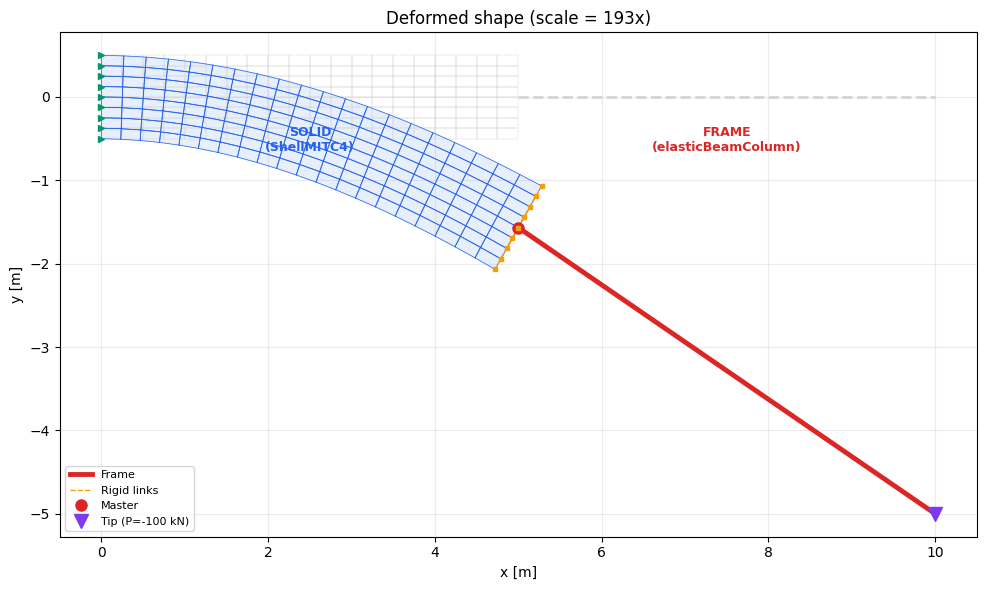

In [12]:
# Collect data
coords, disps = {}, {}
for (i, j), tag in solid_nodes.items():
    coords[tag] = (i * dx, -h/2.0 + j * dy)
    d = ops.nodeDisp(tag)
    disps[tag] = (d[0], d[1])
for tag in [master_tag, tip_tag]:
    c = ops.nodeCoord(tag)
    d = ops.nodeDisp(tag)
    coords[tag] = (c[0], c[1])
    disps[tag]  = (d[0], d[1])

max_d = max(abs(d[1]) for d in disps.values() if abs(d[1]) > 0)
scale = 0.5 * L / max_d if max_d > 0 else 1.0

fig, ax1 = plt.subplots(1, 1, figsize=(16, 6))

# Undeformed (gray)
for (_, n1, n2, n3, n4) in quad_elements:
    xs = [coords[n][0] for n in [n1, n2, n3, n4, n1]]
    ys = [coords[n][1] for n in [n1, n2, n3, n4, n1]]
    ax1.plot(xs, ys, color='#d4d4d4', lw=0.3)
ax1.plot([coords[master_tag][0], coords[tip_tag][0]],
         [coords[master_tag][1], coords[tip_tag][1]],
         '--', color='#d4d4d4', lw=2)

# Deformed solid (blue)
for (_, n1, n2, n3, n4) in quad_elements:
    xs_d = [coords[n][0] + scale*disps[n][0] for n in [n1, n2, n3, n4, n1]]
    ys_d = [coords[n][1] + scale*disps[n][1] for n in [n1, n2, n3, n4, n1]]
    ax1.fill(xs_d[:-1], ys_d[:-1], alpha=0.10, color='#2563EB')
    ax1.plot(xs_d, ys_d, color='#2563EB', lw=0.5)

# Deformed frame (red)
mx = coords[master_tag][0] + scale*disps[master_tag][0]
my = coords[master_tag][1] + scale*disps[master_tag][1]
tx = coords[tip_tag][0] + scale*disps[tip_tag][0]
ty = coords[tip_tag][1] + scale*disps[tip_tag][1]
ax1.plot([mx, tx], [my, ty], '-', color='#DC2626', lw=3.5, label='Frame')

# Rigid links (orange dashed)
for sn in interface_solid_tags:
    sx = coords[sn][0] + scale*disps[sn][0]
    sy = coords[sn][1] + scale*disps[sn][1]
    ax1.plot([mx, sx], [my, sy], '--', color='#F59E0B', lw=1.0)
ax1.plot([], [], '--', color='#F59E0B', lw=1.0, label='Rigid links')

# Markers
ax1.plot(mx, my, 'o', color='#DC2626', ms=8, zorder=5, label='Master')
ax1.plot(tx, ty, 'v', color='#7C3AED', ms=10, zorder=5, label=f'Tip (P={P:.0f} kN)')
for sn in interface_solid_tags:
    ax1.plot(coords[sn][0]+scale*disps[sn][0],
             coords[sn][1]+scale*disps[sn][1], 's', color='#F59E0B', ms=3, zorder=5)
for j in range(ny_s + 1):
    n = solid_nodes[(0, j)]
    ax1.plot(coords[n][0], coords[n][1], '>', color='#059669', ms=5, zorder=5)

ax1.annotate('SOLID\n(ShellMITC4)', xy=(L_solid/2, -h/2-0.15),
             ha='center', fontsize=9, color='#2563EB', weight='bold')
ax1.annotate('FRAME\n(elasticBeamColumn)', xy=(L_solid+L_frame/2, -h/2-0.15),
             ha='center', fontsize=9, color='#DC2626', weight='bold')

ax1.set_title(f'Deformed shape (scale = {scale:.0f}x)', fontsize=12)
ax1.set_xlabel('x [m]')
ax1.set_ylabel('y [m]')
ax1.set_aspect('equal')
ax1.grid(True, alpha=0.25)
ax1.legend(loc='lower left', fontsize=8)
plt.tight_layout()
plt.show()

### 7.2 Deflection Curve vs. Analytical

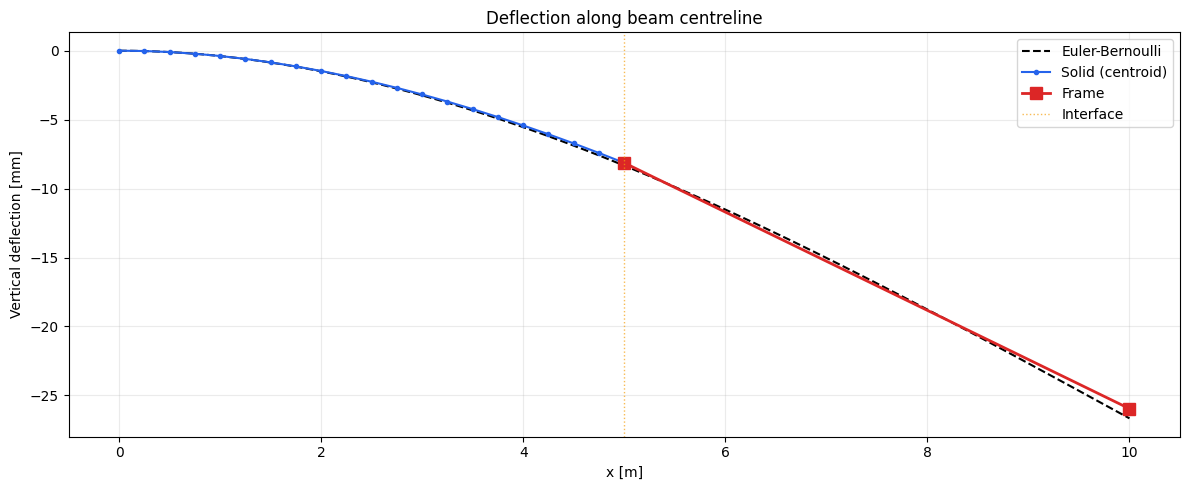

In [13]:
fig, ax2 = plt.subplots(1, 1, figsize=(12, 5))

# Solid centroid
j_mid = ny_s // 2
x_solid  = [coords[solid_nodes[(i, j_mid)]][0] for i in range(nx_s + 1)]
uy_solid = [disps[solid_nodes[(i, j_mid)]][1]   for i in range(nx_s + 1)]

# Frame
x_frame  = [coords[master_tag][0], coords[tip_tag][0]]
uy_frame = [disps[master_tag][1],  disps[tip_tag][1]]

# Analytical
x_an  = np.linspace(0, L, 300)
uy_EB = P / (6.0 * E * Iz) * (3.0 * L * x_an**2 - x_an**3)

ax2.plot(x_an, uy_EB*1e3, 'k--', lw=1.5, label='Euler-Bernoulli')
ax2.plot(x_solid, np.array(uy_solid)*1e3, 'o-', color='#2563EB',
         ms=3, lw=1.5, label='Solid (centroid)')
ax2.plot(x_frame, np.array(uy_frame)*1e3, 's-', color='#DC2626',
         ms=8, lw=2, label='Frame')
ax2.axvline(L_solid, color='#F59E0B', lw=1, ls=':', alpha=0.7, label='Interface')

ax2.set_xlabel('x [m]')
ax2.set_ylabel('Vertical deflection [mm]')
ax2.set_title('Deflection along beam centreline')
ax2.legend()
ax2.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

### 7.3 Interface Cross-Section: Verify Plane Sections Remain Plane

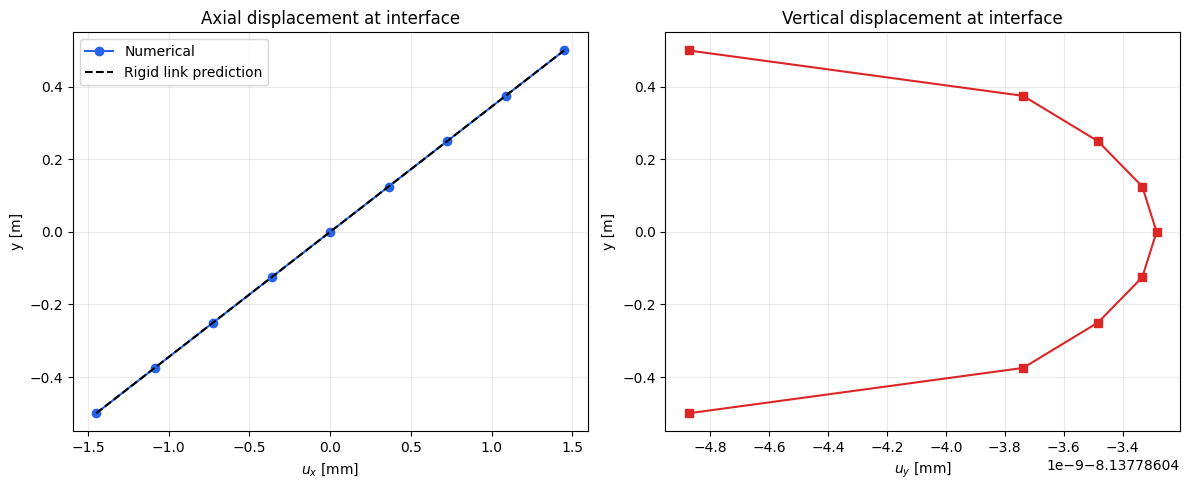

ux is perfectly linear in y: plane sections remain plane ✓
uy is uniform across depth: rigid body translation ✓


In [14]:
fig, (ax_ux, ax_uy) = plt.subplots(1, 2, figsize=(12, 5))

y_arr  = np.array(interface_y)
ux_arr = np.array(interface_ux)
uy_arr = np.array(interface_uy)

# Predicted from rigid body kinematics
ux_predicted = -y_arr * rz_master

ax_ux.plot(ux_arr * 1e3, y_arr, 'o-', color='#2563EB', ms=6, label='Numerical')
ax_ux.plot(ux_predicted * 1e3, y_arr, 'k--', lw=1.5, label='Rigid link prediction')
ax_ux.set_xlabel('$u_x$ [mm]')
ax_ux.set_ylabel('y [m]')
ax_ux.set_title('Axial displacement at interface')
ax_ux.legend()
ax_ux.grid(True, alpha=0.25)

ax_uy.plot(uy_arr * 1e3, y_arr, 's-', color='#DC2626', ms=6)
ax_uy.set_xlabel('$u_y$ [mm]')
ax_uy.set_ylabel('y [m]')
ax_uy.set_title('Vertical displacement at interface')
ax_uy.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

print(f"ux is perfectly linear in y: plane sections remain plane ✓")
print(f"uy is uniform across depth: rigid body translation ✓")

## 8. Summary

### Coupling Technique

| Component | Role |
|-----------|------|
| **Master node** | Located at cross-section centroid; end node of the frame element |
| **Duplicated nodes** | Co-located with solid interface nodes; have full DOFs (translations + rotations); not connected to any element |
| **`rigidLink('beam')`** | Master → dup nodes: enforces rigid body kinematics (plane sections remain plane) |
| **`equalDOF`** | Dup → solid nodes (DOFs 1,2 only): transfers translations without imposing rotations on the solid mesh |
| **Penalty handler** | Required because dup nodes are slaves in `rigidLink` AND retained in `equalDOF` (nested MP constraints) |

### Why Not Apply `rigidLink` Directly to Solid Nodes?

Solid elements have **no rotational stiffness**. Applying `rigidLink('beam')` directly would impose a rotation DOF ($\theta_z$) on a node where no element provides resistance to it. The duplicated nodes absorb the rotation from the rigid link and pass only the translations to the solid mesh via `equalDOF`.

### Results

The numerical solution matches the Euler-Bernoulli analytical solution to within ~3%, which is expected for a shell/solid mesh that captures shear deformation effects not present in classical beam theory.

## 9. Gmsh Visualization (Interactive Deformed Shape)

Now we rebuild the mesh in Gmsh using **pyGmsh**, map the OpenSees displacement results onto it, and launch the Gmsh GUI for interactive post-processing.

The workflow:
1. Create the solid domain geometry and structured mesh with pyGmsh
2. Extract the `NumberedMesh` to get the Gmsh↔solver node mapping
3. Map displacement results from OpenSees node tags → Gmsh node tags
4. Create Gmsh post-processing views (displacement vector for deformed shape, scalar contours)
5. Export `.msh` and launch the GUI

In [15]:
import sys, os

# Add pyGmsh source to path (relative to this notebook's location)
_nb_dir = os.path.dirname(os.path.abspath("cantilever_solid_frame_coupling.ipynb"))
_src_dir = os.path.join(_nb_dir, "src")
if _src_dir not in sys.path:
    sys.path.insert(0, _src_dir)

from pyGmsh import pyGmsh

# ── 9.1  Build the solid + frame mesh in Gmsh ───────────────────────
g = pyGmsh(model_name="cantilever_coupling")
g.initialize()

# Solid region geometry
p1 = g.model.add_point(0.0, -h/2, 0.0)
p2 = g.model.add_point(L_solid, -h/2, 0.0)
p3 = g.model.add_point(L_solid,  h/2, 0.0)
p4 = g.model.add_point(0.0,  h/2, 0.0)

# Frame endpoints (centroid at interface → tip)
p_master = g.model.add_point(L_solid, 0.0, 0.0)
p_tip    = g.model.add_point(L,       0.0, 0.0)

l1 = g.model.add_line(p1, p2)
l2 = g.model.add_line(p2, p3)
l3 = g.model.add_line(p3, p4)
l4 = g.model.add_line(p4, p1)
l_frame = g.model.add_line(p_master, p_tip)

cl = g.model.add_curve_loop([l1, l2, l3, l4])
s1 = g.model.add_plane_surface([cl])

# Physical groups
g.physical.add(2, [s1],      name="SolidRegion")
g.physical.add(1, [l4],      name="FixedSupport")
g.physical.add(1, [l2],      name="Interface")
g.physical.add(1, [l_frame], name="FrameElement")

# Transfinite (structured) mesh
import gmsh
gmsh.model.mesh.setTransfiniteCurve(l1, nx_s + 1)
gmsh.model.mesh.setTransfiniteCurve(l3, nx_s + 1)
gmsh.model.mesh.setTransfiniteCurve(l2, ny_s + 1)
gmsh.model.mesh.setTransfiniteCurve(l4, ny_s + 1)
gmsh.model.mesh.setTransfiniteSurface(s1)
gmsh.model.mesh.setRecombine(2, s1)
gmsh.model.mesh.setTransfiniteCurve(l_frame, 2)  # 1 frame element

g.mesh.set_order(1)
g.mesh.generate(2)

# Get numbered mesh for mapping (solid elements only)
nm = g.mesh.get_numbered_mesh(dim=2, method="simple")
print(f"Gmsh mesh: {nm.n_nodes} solid nodes, {nm.n_elems} elements + 1 frame line")

Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 30%] Meshing curve 2 (Line)
Info    : [ 50%] Meshing curve 3 (Line)
Info    : [ 70%] Meshing curve 4 (Line)
Info    : [ 90%] Meshing curve 5 (Line)
Info    : Done meshing 1D (Wall 0.000136156s, CPU 0.000127s)
Info    : Meshing 2D...
Info    : Meshing surface 1 (Transfinite)
Info    : Done meshing 2D (Wall 0.000125515s, CPU 0.00032s)
Info    : 191 nodes 223 elements
Gmsh mesh: 189 solid nodes, 160 elements + 1 frame line


In [16]:
# ── 9.2  Map OpenSees displacements → Gmsh node tags ────────────────
#
# Solid nodes: numbered mesh gives us solver_id ↔ gmsh_tag mapping
# Frame nodes: get their Gmsh tags from the FrameElement physical group

# --- Solid nodes ---
gmsh_tags_solid = np.array([nm.solver_to_gmsh_node[sid]
                             for sid in range(1, nm.n_nodes + 1)])
disp_solid = np.zeros((nm.n_nodes, 3))
for solver_id in range(1, nm.n_nodes + 1):
    d = ops.nodeDisp(solver_id)
    disp_solid[solver_id - 1, 0] = d[0]
    disp_solid[solver_id - 1, 1] = d[1]

# --- Frame nodes (master + tip) ---
frame_pg = g.physical.get_nodes(1, 4)  # tag=4, "FrameElement"
frame_gmsh_tags = frame_pg['tags']
frame_coords = frame_pg['coords'].reshape(-1, 3)

disp_frame = np.zeros((len(frame_gmsh_tags), 3))
for i, gt in enumerate(frame_gmsh_tags):
    cx, cy = frame_coords[i, 0], frame_coords[i, 1]
    if abs(cx - L_solid) < 1e-6 and abs(cy) < 1e-6:
        d = ops.nodeDisp(master_tag)
    elif abs(cx - L) < 1e-6 and abs(cy) < 1e-6:
        d = ops.nodeDisp(tip_tag)
    else:
        d = [0.0] * 6
    disp_frame[i, 0] = d[0]
    disp_frame[i, 1] = d[1]

# --- Concatenate ---
gmsh_tags_ordered = np.concatenate([gmsh_tags_solid, frame_gmsh_tags.astype(int)])
disp_array = np.vstack([disp_solid, disp_frame])
disp_mag   = np.linalg.norm(disp_array, axis=1)
ux_vals    = disp_array[:, 0]
uy_vals    = disp_array[:, 1]

n_total = len(gmsh_tags_ordered)
print(f"View nodes: {n_total} (solid={nm.n_nodes}, frame={len(frame_gmsh_tags)})")
print(f"|disp| range: [{disp_mag.min():.3e}, {disp_mag.max():.3e}] m")

View nodes: 191 (solid=189, frame=2)
|disp| range: [2.751e-13, 2.597e-02] m


In [17]:
# ── 9.3  Create Gmsh post-processing views ──────────────────────────
import gmsh

node_tags_list = list(gmsh_tags_ordered.astype(int))

# View 0: Displacement vector (raw — kept hidden, used as deformation source)
v1 = g.view.add_node_vector(
    "Displacement [m]",
    node_tags=node_tags_list,
    vectors=disp_array,
    vector_type=5            # displacement: deforms the mesh
)

# View 1: Displacement magnitude contour (main visible view)
v2 = g.view.add_node_scalar(
    "|Displacement| [m]",
    node_tags=node_tags_list,
    values=disp_mag.tolist()
)

# View 2: uy contour (hidden by default)
v3 = g.view.add_node_scalar(
    "uy [m]",
    node_tags=node_tags_list,
    values=uy_vals.tolist()
)

# View 3: ux contour (hidden by default)
v4 = g.view.add_node_scalar(
    "ux [m]",
    node_tags=node_tags_list,
    values=ux_vals.tolist()
)

# ── Configure views: only ONE visible at a time ─────────────────────
# Hide the raw displacement vector view
gmsh.view.option.setNumber(v1, "Visible", 0)

# |Displacement| contour on deformed shape — primary view
gmsh.view.option.setNumber(v2, "Visible", 1)
gmsh.view.option.setNumber(v2, "DisplacementFactor", 200.0)
gmsh.view.option.setNumber(v2, "ShowElement", 1)
gmsh.view.option.setNumber(v2, "ColormapNumber", 2)        # Jet
gmsh.view.option.setNumber(v2, "IntervalsType", 2)         # continuous
gmsh.view.option.setNumber(v2, "NbIso", 20)

# uy and ux: hidden, but pre-configured for when toggled on
for v in [v3, v4]:
    gmsh.view.option.setNumber(v, "Visible", 0)
    gmsh.view.option.setNumber(v, "DisplacementFactor", 200.0)
    gmsh.view.option.setNumber(v, "ShowElement", 1)
    gmsh.view.option.setNumber(v, "ColormapNumber", 2)
    gmsh.view.option.setNumber(v, "IntervalsType", 2)
    gmsh.view.option.setNumber(v, "NbIso", 20)

# Hide underlying mesh edges (the view draws its own)
gmsh.option.setNumber("Mesh.SurfaceEdges", 0)
gmsh.option.setNumber("Mesh.SurfaceFaces", 0)

# Set 2D XY viewing angle
gmsh.option.setNumber("General.Trackball", 0)
gmsh.option.setNumber("General.RotationX", 0)
gmsh.option.setNumber("General.RotationY", 0)
gmsh.option.setNumber("General.RotationZ", 0)

print("Gmsh views configured:")
print("  [visible]  |Displacement| contour on deformed shape (200x)")
print("  [hidden]   uy, ux contours (toggle in GUI sidebar)")

Gmsh views configured:
  [visible]  |Displacement| contour on deformed shape (200x)
  [hidden]   uy, ux contours (toggle in GUI sidebar)


In [18]:
# ── 9.4  Export and launch GUI ────────────────────────────────────────
out_msh = "cantilever_solid_frame_deformed.msh"
gmsh.option.setNumber("Mesh.SaveAll", 1)
gmsh.write(out_msh)
print(f"Exported: {out_msh}")

# Launch Gmsh GUI (interactive window — close it to continue)
# Uncomment the next line to open the GUI:
# g.launch_gui()

print("\nTo view interactively, run:  gmsh cantilever_solid_frame_deformed.msh")

Info    : Writing 'cantilever_solid_frame_deformed.msh'...
Exported: cantilever_solid_frame_deformed.msh

To view interactively, run:  gmsh cantilever_solid_frame_deformed.msh
Info    : Done writing 'cantilever_solid_frame_deformed.msh'


## 10. Cleanup

In [19]:
ops.wipe()
g.finalize()
print("OpenSees model wiped. Gmsh finalized. Done!")

OpenSees model wiped. Gmsh finalized. Done!
